In [1]:
!pip install torch_geometric
import torch
import torch.nn.functional as funcy
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00


In [2]:
data=Planetoid(root='data/Cora',name='Cora')

Processing...
Done!


In [3]:
d=data[0]

In [4]:
d

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [5]:
import torch.nn as nn

In [6]:
class vGN(nn.Module):
    def __init__(self,inn,hid,out):
        super().__init__()
        self.c1=GCNConv(inn,hid)
        self.c2=GCNConv(hid,out)
    def forward(self,x,ei):
        x=self.c1(x,ei)
        x=funcy.relu(x)
        x=self.c2(x,ei)
        return x

In [7]:
mod=vGN(data.num_node_features,16,data.num_classes)

In [8]:
mod

vGN(
  (c1): GCNConv(1433, 16)
  (c2): GCNConv(16, 7)
)

In [9]:
optim=torch.optim.Adam(mod.parameters(),lr=1e-2,weight_decay=5e-4)

In [10]:
for ep in range(201):
    mod.train()
    optim.zero_grad()
    o=mod(d.x,d.edge_index)
    loss=funcy.cross_entropy(o[d.train_mask],d.y[d.train_mask])
    loss.backward()
    optim.step()

    mod.eval()
    with torch.no_grad():
        o=mod(d.x,d.edge_index)
        pr=o.argmax(dim=1)
        mets=[]
        for m in [d.train_mask,d.val_mask,d.test_mask]:
            met=(pr[m]==d.y[m]).sum()/m.sum()
            mets.append(met.item())
    ta,va,tea=mets
    if ep%20==0:
        print(f"Epoch {ep}, Loss: {loss:.4f}, Train Acc: {ta:.4f}, Val Acc: {va:.4f}, Test Acc: {tea:.4f}")

Epoch 0, Loss: 1.9474, Train Acc: 0.6429, Val Acc: 0.3160, Test Acc: 0.3330
Epoch 20, Loss: 0.1482, Train Acc: 1.0000, Val Acc: 0.7640, Test Acc: 0.7910
Epoch 40, Loss: 0.0171, Train Acc: 1.0000, Val Acc: 0.7680, Test Acc: 0.7930
Epoch 60, Loss: 0.0167, Train Acc: 1.0000, Val Acc: 0.7680, Test Acc: 0.8040
Epoch 80, Loss: 0.0193, Train Acc: 1.0000, Val Acc: 0.7740, Test Acc: 0.8020
Epoch 100, Loss: 0.0174, Train Acc: 1.0000, Val Acc: 0.7600, Test Acc: 0.7930
Epoch 120, Loss: 0.0153, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.7960
Epoch 140, Loss: 0.0139, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.7980
Epoch 160, Loss: 0.0128, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7940
Epoch 180, Loss: 0.0119, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7970
Epoch 200, Loss: 0.0112, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.8000


In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

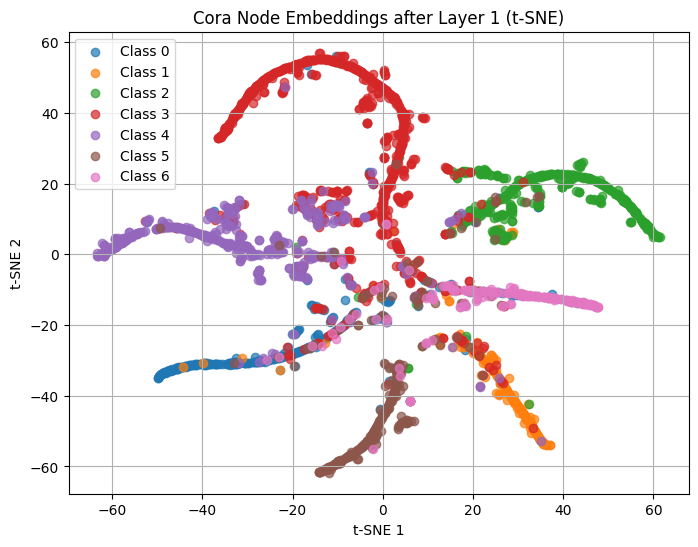

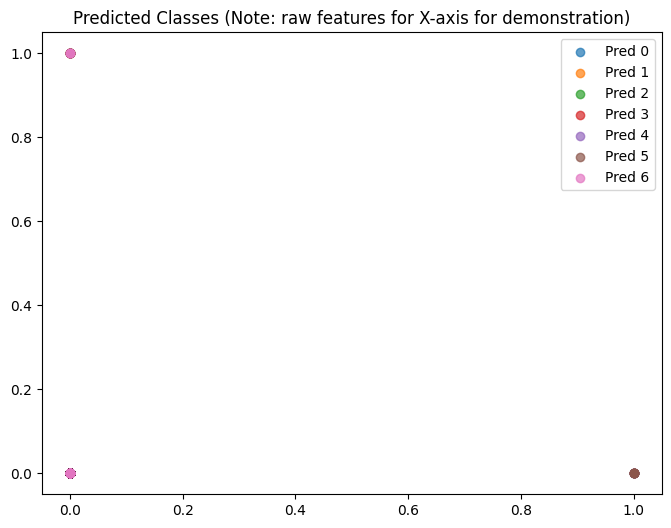

In [12]:
mod.eval()
out= mod(d.x, d.edge_index)
h1=funcy.relu(out)
h1_2d = TSNE(n_components=2, random_state=42).fit_transform(h1.detach().numpy())
plt.figure(figsize=(8,6))
for i in range(data.num_classes):
    idx = (d.y == i)
    plt.scatter(h1_2d[idx,0], h1_2d[idx,1], label=f'Class {i}', alpha=0.7)

plt.legend()
plt.title("Cora Node Embeddings after Layer 1 (t-SNE)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()
pred = out.argmax(dim=1)

plt.figure(figsize=(8,6))
for i in range(data.num_classes):
    idx = (pred == i)
    plt.scatter(d.x[idx,0].numpy(), d.x[idx,1].numpy(), label=f'Pred {i}', alpha=0.7)
plt.legend()
plt.title("Predicted Classes (Note: raw features for X-axis for demonstration)")
plt.show()